# Practical Session 06b &mdash; The dual and the kernel trick

**Companion to Lectures&nbsp;06 and&nbsp;07.** Second of three notebooks &mdash; the bridge between the
two sessions.

| # | Notebook | Topic |
|---|----------|-------|
| 06a | The margin and the soft margin | the widest band, support vectors, $C$, the hinge |
| **06b** | **The dual and the kernel trick** | **the prices $\alpha_i$, KKT, inner products only &mdash; the bridge to Session&nbsp;07 (this notebook)** |
| 07 | Kernels in practice | valid kernels, the zoo, $\gamma$, kernel ridge regression |

Notebook&nbsp;06a let scikit-learn fit every SVM. Here we **solve the SVM ourselves** &mdash; not with a
special-purpose algorithm, but by writing down the **dual problem** and handing it to SciPy's general
optimizer. The dual is worth the trouble for one reason: its unknowns are $n$ **prices**
$\alpha_1,\dots,\alpha_n$, one per training point, and the data enter **only through inner products**
$\mathbf{x}_i^\top\mathbf{x}_j$. Replace those inner products and the same code draws curved boundaries.
That is the kernel trick.

> &#11088; **Key idea.** Maximize
> $\sum_i\alpha_i-\tfrac12\sum_{i,j}\alpha_i\alpha_j\,y_iy_j\,\mathbf{x}_i^\top\mathbf{x}_j$ subject to
> $0\le\alpha_i\le C$ and $\sum_i\alpha_iy_i=0$. Then $\mathbf{w}=\sum_i\alpha_iy_i\mathbf{x}_i$, and a
> prediction needs only the inner products $\mathbf{x}_i^\top\mathbf{x}$.

> &#9888;&#65039; **Scope.** SciPy's general solver is accurate but scales roughly like $n^3$, and past about
> 200 points it may stop without converging. Keep it to **$n\le200$** points. For anything bigger use
> `SVC`, whose dual solution we can also read, as we do below.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.svm import SVC
from sklearn.datasets import make_moons

from nb_utils import use_style
from nb_data import make_two_blobs, make_rings

use_style("notes")
C0, C1, CG = "#0072B2", "#D55E00", "#009E73"      # class -1, class +1, the boundary
print("ready")

ready


## 1. The dual, written as code

Collect the inner products in the $n\times n$ matrix $K_{ij}=\mathbf{x}_i^\top\mathbf{x}_j$ &mdash; for a
data matrix $\mathbf{X}$ that is simply `K = X @ X.T` &mdash; and set $Q_{ij}=y_iy_j\,K_{ij}$. The dual
objective is a quadratic in the vector $\boldsymbol\alpha$:

$$W(\boldsymbol\alpha)=\mathbf{1}^\top\boldsymbol\alpha-\tfrac12\,\boldsymbol\alpha^\top Q\,\boldsymbol\alpha,
\qquad \nabla W=\mathbf{1}-Q\boldsymbol\alpha .$$

SciPy *minimizes*, so we give it $-W$ and $-\nabla W$, the box $0\le\alpha_i\le C$ (no upper bound for
the hard margin &mdash; which only makes sense for separable data; otherwise the prices grow without
bound), and the single equality $\boldsymbol\alpha^\top\mathbf{y}=0$.

Once the prices are known, the model takes two lines:

* $\mathbf{w}=\sum_i\alpha_iy_i\mathbf{x}_i$;
* $b=y_k-\mathbf{w}^\top\mathbf{x}_k$ for a **free** support vector $k$ &mdash; one with $0<\alpha_k<C$,
  which sits exactly on its margin line. We average over all of them.

In [2]:
def solve_dual(K, y, C=None):
    "maximize the SVM dual for a Gram matrix K and labels y in {-1,+1}; returns alpha"
    y = y.astype(float)
    Q = np.outer(y, y) * K
    result = minimize(
        fun=lambda a: 0.5 * a @ Q @ a - a.sum(),          # -W(alpha)
        jac=lambda a: Q @ a - 1.0,                        # -grad W(alpha)
        x0=np.zeros(len(y)),
        method="SLSQP",
        bounds=[(0.0, C)] * len(y),                       # C = None: no upper bound (hard margin)
        constraints=[{"type": "eq", "fun": lambda a: a @ y, "jac": lambda a: y}],
        options={"ftol": 1e-12, "maxiter": 1000})
    assert result.success, result.message
    return result.x


def free_mask(alpha, C=None, tol=1e-6):
    "support vectors strictly inside the box -- the ones sitting exactly on a margin line"
    upper = np.inf if C is None else C - tol
    return (alpha > tol) & (alpha < upper)


def recover_w_b(alpha, X, y, C=None):
    w = (alpha * y) @ X                                   # w = sum_i alpha_i y_i x_i
    k = free_mask(alpha, C)
    b = np.mean(y[k] - X[k] @ w)                          # b = y_k - w.x_k, averaged over free SVs
    return w, b


X3 = np.array([[2.0, 0.0], [0.0, 2.0], [0.0, 0.0]])
y3 = np.array([1, 1, -1])

alpha3 = solve_dual(X3 @ X3.T, y3)                        # hard margin
w3, b3 = recover_w_b(alpha3, X3, y3)
print("alpha =", alpha3.round(12), "   (lecture: 1/2, 1/2, 1)")
print("w     =", w3.round(12), "   b =", round(b3, 12))

alpha = [0.5 0.5 1. ]    (lecture: 1/2, 1/2, 1)
w     = [1. 1.]    b = -1.0


Those are the lecture's numbers **exactly**, to every printed digit &mdash; where `SVC` in notebook&nbsp;06a
stopped at $0.9995$. Now read the prices. Each identity below was derived in the lecture, and each is a
single line to check.

In [3]:
Q3 = np.outer(y3, y3) * (X3 @ X3.T)
W = alpha3.sum() - 0.5 * alpha3 @ Q3 @ alpha3
print(f"balance       sum alpha_i y_i  = {alpha3 @ y3: .1e}    (the equality constraint)")
print(f"dual value    W(alpha)         = {W:.12f}")
print(f"primal value  (1/2)||w||^2     = {0.5 * w3 @ w3:.12f}    equal: strong duality")
print(f"hard margin   sum alpha_i      = {alpha3.sum():.12f}")
print(f"              ||w||^2          = {w3 @ w3:.12f}    equal")

print("\nfunctional margins y*f(x):", (y3 * (X3 @ w3 + b3)).round(12), "-> every constraint is tight")

X4, y4 = np.vstack([X3, [3.0, 3.0]]), np.append(y3, 1)   # a far-away bystander
alpha4 = solve_dual(X4 @ X4.T, y4)
print("\nadd x4 = (3, 3):  alpha =", alpha4.round(10), "-> the new point pays nothing")

balance       sum alpha_i y_i  = -1.1e-16    (the equality constraint)
dual value    W(alpha)         = 1.000000000000
primal value  (1/2)||w||^2     = 1.000000000000    equal: strong duality
hard margin   sum alpha_i      = 2.000000000000
              ||w||^2          = 2.000000000000    equal

functional margins y*f(x): [1. 1. 1.] -> every constraint is tight

add x4 = (3, 3):  alpha = [0.5 0.5 1.  0. ] -> the new point pays nothing


## 2. The soft margin: every point lands in one of three cases

With overlapping classes the upper bound $C$ matters, and the KKT conditions sort **every** training
point into exactly one case. Writing $m_i=y_if(\mathbf{x}_i)$:

| price | margin | meaning |
|---|---|---|
| $\alpha_i=0$ | $m_i\ge1$ | outside the band &mdash; a bystander |
| $0<\alpha_i<C$ | $m_i=1$ | exactly **on** its margin line &mdash; a *free* support vector |
| $\alpha_i=C$ | $m_i\le1$ | inside the band or misclassified &mdash; pushing as hard as it is allowed |

We solve an 80-point problem, compare with `SVC`, and check the table row by row.

our     w, b: [ 1.467739 -0.274511] -0.204419
sklearn w, b: [ 1.467738 -0.274511] -0.20442

alpha = 0    :  46 points, margins from   1.0075 to   4.3621
0 < alpha < C:   3 points, margins from   1.0000 to   1.0000
alpha = C    :  31 points, margins from  -1.9528 to   0.9375

each row of the table, checked to within 1e-5:
  alpha = 0      ->  m >= 1 : True
  0 < alpha < C  ->  m  = 1 : True
  alpha = C      ->  m <= 1 : True


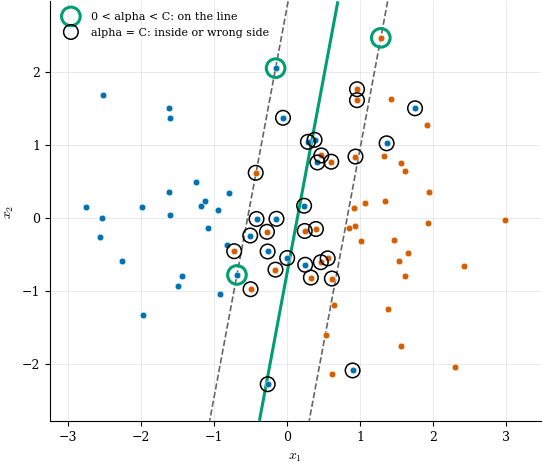

In [4]:
X, y = make_two_blobs(n=80, sep=0.8, seed=3)
C = 1.0

alpha = solve_dual(X @ X.T, y, C)
w, b = recover_w_b(alpha, X, y, C)
svm = SVC(kernel="linear", C=C, tol=1e-10).fit(X, y)
print("our     w, b:", w.round(6), round(b, 6))
print("sklearn w, b:", svm.coef_[0].round(6), round(float(svm.intercept_[0]), 6))

m = y * (X @ w + b)
tol = 1e-6
cases = {"alpha = 0    ": alpha <= tol,
         "0 < alpha < C": free_mask(alpha, C, tol),
         "alpha = C    ": alpha >= C - tol}
print()
for name, mask in cases.items():
    print(f"{name}: {mask.sum():3d} points, margins from {m[mask].min():8.4f} to {m[mask].max():8.4f}")
a0, free, aC = cases.values()
print("\neach row of the table, checked to within 1e-5:")
print("  alpha = 0      ->  m >= 1 :", bool((m[a0] >= 1 - 1e-5).all()))
print("  0 < alpha < C  ->  m  = 1 :", bool(np.allclose(m[free], 1, atol=1e-5)))
print("  alpha = C      ->  m <= 1 :", bool((m[aC] <= 1 + 1e-5).all()))

gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 300),
                     np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 300))
F = (np.column_stack([gx.ravel(), gy.ravel()]) @ w + b).reshape(gx.shape)
fig, ax = plt.subplots(figsize=(6.0, 4.7))
ax.contour(gx, gy, F, levels=[-1, 0, 1], colors=["0.4", CG, "0.4"],
           linestyles=["--", "-", "--"], linewidths=[1.2, 2.2, 1.2])
for lab, c in ((-1, C0), (1, C1)):
    ax.scatter(*X[y == lab].T, s=22, color=c, edgecolor="white", linewidth=0.3, zorder=3)
ax.scatter(*X[free].T, s=180, facecolor="none", edgecolor=CG, linewidth=2.2,
           zorder=4, label="0 < alpha < C: on the line")
ax.scatter(*X[aC].T, s=110, facecolor="none", edgecolor="black", linewidth=1.1,
           zorder=4, label="alpha = C: inside or wrong side")
ax.set_aspect("equal"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.legend(fontsize=8, loc="upper left")
plt.show()

## 3. Sparsity: the model forgets most of its training set

Points with $\alpha_i=0$ contribute nothing to $\mathbf{w}=\sum_i\alpha_iy_i\mathbf{x}_i$. So we should be
able to **delete every non-support vector, refit, and get the same classifier**. At 400 points we are past
SciPy's comfortable range, so `SVC` does the solving &mdash; with a tight tolerance, so that any difference
is real rather than the solver stopping early.

In [5]:
Xbig, ybig = make_two_blobs(n=400, sep=1.2, seed=0)
full = SVC(kernel="linear", C=1.0, tol=1e-10).fit(Xbig, ybig)
keep = full.support_
only_sv = SVC(kernel="linear", C=1.0, tol=1e-10).fit(Xbig[keep], ybig[keep])

diff = np.abs(full.decision_function(Xbig) - only_sv.decision_function(Xbig)).max()
print(f"kept {len(keep)} of {len(ybig)} points ({100 * len(keep) / len(ybig):.0f}%)")
print(f"largest change in f(x) over all {len(ybig)} points: {diff:.1e}")

kept 118 of 400 points (30%)
largest change in f(x) over all 400 points: 5.5e-11


## 4. A prediction needs only inner products

Substitute $\mathbf{w}=\sum_i\alpha_iy_i\mathbf{x}_i$ into the score:

$$f(\mathbf{x})=\sum_{i\in\text{SV}}\alpha_iy_i\;\mathbf{x}_i^\top\mathbf{x}\;+\;b .$$

`SVC` stores exactly these pieces: `support_vectors_` (the $\mathbf{x}_i$), `dual_coef_` (the products
$\alpha_iy_i$) and `intercept_` ($b$). So we can rebuild its `decision_function` by hand &mdash; and nothing
in the formula cares *which* inner product we use. Put another similarity $K(\mathbf{x}_i,\mathbf{x})$ in
its place, and the same line reproduces an RBF or a polynomial SVM.

In [6]:
Xm, ym = make_moons(n_samples=200, noise=0.25, random_state=0)
ym = np.where(ym == 1, 1, -1)


def rbf_kernel(A, B, gamma):
    "K(a, b) = exp(-gamma ||a - b||^2) for every pair of rows"
    sq = (A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :] - 2 * A @ B.T
    return np.exp(-gamma * np.maximum(sq, 0.0))


kernels = {
    "linear": (dict(kernel="linear"),
               lambda A, B: A @ B.T),
    "rbf":    (dict(kernel="rbf", gamma=0.7),
               lambda A, B: rbf_kernel(A, B, 0.7)),
    "poly":   (dict(kernel="poly", degree=3, gamma=0.5, coef0=1.0),
               lambda A, B: (0.5 * A @ B.T + 1.0) ** 3),     # sklearn's form: (gamma a.b + coef0)^degree
}
for name, (params, K) in kernels.items():
    s = SVC(C=1.0, **params).fit(Xm, ym)
    f_hand = s.dual_coef_[0] @ K(s.support_vectors_, Xm) + s.intercept_[0]
    print(f"{name:6s}: max |by hand - decision_function| = {np.abs(f_hand - s.decision_function(Xm)).max():.1e}"
          f"   ({len(s.support_)} support vectors)")

linear: max |by hand - decision_function| = 1.8e-14   (76 support vectors)
rbf   : max |by hand - decision_function| = 1.2e-14   (67 support vectors)
poly  : max |by hand - decision_function| = 7.1e-14   (65 support vectors)


## 5. The kernel trick: first with a feature map, then without one

No line separates two concentric rings. Lecture&nbsp;06 lifted them with the explicit map
$\phi(\mathbf{x})=(x_1^2,\ \sqrt2\,x_1x_2,\ x_2^2)$, in which a **flat plane** separates them, and showed the
identity

$$\phi(\mathbf{x})^\top\phi(\mathbf{z})=(\mathbf{x}^\top\mathbf{z})^2 .$$

So the same classifier can be trained two ways: build the three features and run a **linear** SVM, or skip
$\phi$ entirely and run a **polynomial-kernel** SVM with $K(\mathbf{x},\mathbf{z})=(\mathbf{x}^\top\mathbf{z})^2$.
If the identity is right, the two must agree.

lecture's numbers:  (x.z)^2 = 1.000000000000   phi(x).phi(z) = 1.000000000000
max |f_lifted - f_kernel| over the data: 5.8e-15

in the lifted space the boundary is a flat plane:  1.039 x1^2 -0.007 sqrt(2) x1 x2 +1.027 x2^2 -2.029 = 0
back in the plane it is (nearly) the circle  x1^2 + x2^2 = 1.96


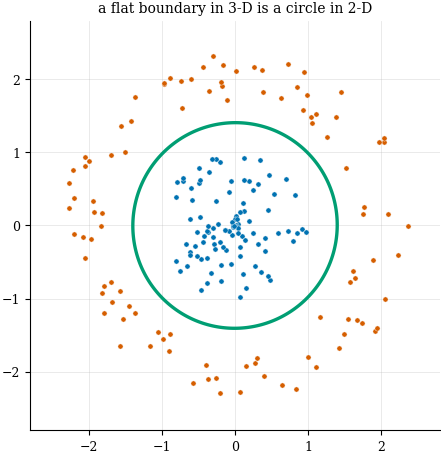

In [7]:
def phi(X):
    "the explicit quadratic feature map, one row per point"
    return np.column_stack([X[:, 0] ** 2, np.sqrt(2) * X[:, 0] * X[:, 1], X[:, 1] ** 2])

x, z = np.array([[1.0, 2.0]]), np.array([[3.0, -1.0]])
print(f"lecture's numbers:  (x.z)^2 = {(x @ z.T).item() ** 2:.12f}   phi(x).phi(z) = {(phi(x) @ phi(z).T).item():.12f}")

Xr, yr = make_rings(n=200, seed=0)
lifted = SVC(kernel="linear", C=10).fit(phi(Xr), yr)                           # build phi, go linear
kernel = SVC(kernel="poly", degree=2, gamma=1.0, coef0=0.0, C=10).fit(Xr, yr)   # never build phi
print(f"max |f_lifted - f_kernel| over the data: "
      f"{np.abs(lifted.decision_function(phi(Xr)) - kernel.decision_function(Xr)).max():.1e}")

wl, bl = lifted.coef_[0], lifted.intercept_[0]
print(f"\nin the lifted space the boundary is a flat plane:"
      f"  {wl[0]:.3f} x1^2 {wl[1]:+.3f} sqrt(2) x1 x2 {wl[2]:+.3f} x2^2 {bl:+.3f} = 0")
print(f"back in the plane it is (nearly) the circle  x1^2 + x2^2 = {-bl / wl[[0, 2]].mean():.2f}")

gx, gy = np.meshgrid(np.linspace(-2.8, 2.8, 300), np.linspace(-2.8, 2.8, 300))
G = np.column_stack([gx.ravel(), gy.ravel()])
fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.contour(gx, gy, kernel.decision_function(G).reshape(gx.shape), levels=[0], colors=CG, linewidths=2.4)
for lab, c in ((-1, C0), (1, C1)):
    ax.scatter(*Xr[yr == lab].T, s=14, color=c, edgecolor="white", linewidth=0.3)
ax.set_aspect("equal"); ax.set_title("a flat boundary in 3-D is a circle in 2-D", fontsize=10)
plt.show()

support vectors: ours 51, sklearn 51
same predicted labels on the data: 1.000
max |f_ours - f_sklearn|: 7.0e-07


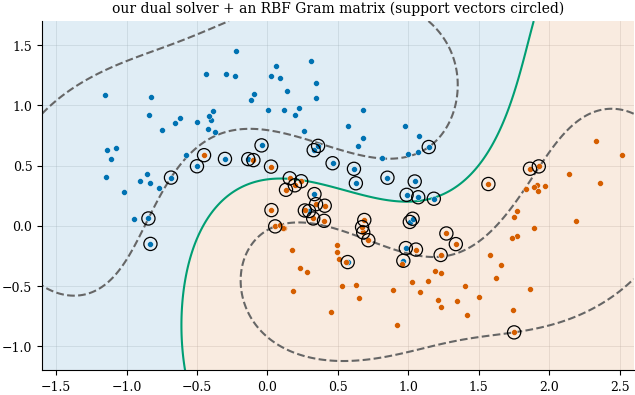

In [8]:
# the payoff: OUR dual solver from section 1, with one line changed -- the Gram matrix
Xmoon, ymoon = make_moons(n_samples=150, noise=0.25, random_state=1)
ymoon = np.where(ymoon == 1, 1, -1)
gamma, C = 0.7, 1.0

K = rbf_kernel(Xmoon, Xmoon, gamma)                       # <-- was: K = X @ X.T
alpha_k = solve_dual(K, ymoon, C)

sv = alpha_k > 1e-6
k = free_mask(alpha_k, C)
b_k = np.mean(ymoon[k] - (alpha_k * ymoon) @ K[:, k])     # b = y_k - sum_i alpha_i y_i K(x_i, x_k)


def f_ours(Xq):
    "f(x) = sum_i alpha_i y_i K(x_i, x) + b, over our support vectors"
    return (alpha_k[sv] * ymoon[sv]) @ rbf_kernel(Xmoon[sv], Xq, gamma) + b_k


ref = SVC(kernel="rbf", gamma=gamma, C=C, tol=1e-10).fit(Xmoon, ymoon)
print(f"support vectors: ours {sv.sum()}, sklearn {len(ref.support_)}")
print(f"same predicted labels on the data: {np.mean(np.sign(f_ours(Xmoon)) == ref.predict(Xmoon)):.3f}")
print(f"max |f_ours - f_sklearn|: {np.abs(f_ours(Xmoon) - ref.decision_function(Xmoon)).max():.1e}")

gx, gy = np.meshgrid(np.linspace(-1.6, 2.6, 250), np.linspace(-1.2, 1.7, 250))
G = np.column_stack([gx.ravel(), gy.ravel()])
Fg = f_ours(G).reshape(gx.shape)
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.contourf(gx, gy, Fg, levels=[Fg.min() - 1, 0, Fg.max() + 1], colors=[C0, C1], alpha=0.12)
ax.contour(gx, gy, Fg, levels=[-1, 0, 1], colors=["0.4", CG, "0.4"], linestyles=["--", "-", "--"])
for lab, c in ((-1, C0), (1, C1)):
    ax.scatter(*Xmoon[ymoon == lab].T, s=18, color=c, edgecolor="white", linewidth=0.3, zorder=3)
ax.scatter(*Xmoon[sv].T, s=90, facecolor="none", edgecolor="black", linewidth=0.9, zorder=4)
ax.set_title("our dual solver + an RBF Gram matrix (support vectors circled)", fontsize=10)
plt.show()

## Recap & exercises

**Recap.**
* The dual has one **price** $\alpha_i$ per point. SciPy's general optimizer solves it accurately for small
  $n$: the lecture's $\boldsymbol\alpha=(\tfrac12,\tfrac12,1)$, $\mathbf{w}=(1,1)$, $b=-1$ came out to every
  printed digit.
* $\mathbf{w}=\sum_i\alpha_iy_i\mathbf{x}_i$, and $b$ comes from a **free** support vector.
* **Strong duality:** $W(\boldsymbol\alpha^\ast)=\tfrac12\lVert\mathbf{w}\rVert^2$; for the hard margin also
  $\sum_i\alpha_i=\lVert\mathbf{w}\rVert^2$.
* **KKT** puts every point in one of three cases, readable straight off $\alpha_i$ and its margin.
* **Sparsity:** refitting on the support vectors alone leaves $f$ unchanged.
* Training and prediction touch the data **only through inner products**. A lifted linear SVM and a
  polynomial-kernel SVM agreed to rounding error, and one changed line turned our solver into an RBF SVM.

**Exercises.**
1. In &sect;1, add the point $(0.5,0.5)$ labeled $+1$ &mdash; it sits on the old boundary. Solve again:
   which prices change, and how wide is the new band?
2. In &sect;2, sweep $C$ over `[0.01, 0.1, 1, 10]` and count the three cases each time. Which case grows
   as $C$ shrinks? Explain it with the box $0\le\alpha_i\le C$.
3. In &sect;4, fit `SVC(kernel="poly", degree=3, coef0=1)` **without** setting `gamma` and rebuild it with
   $(\mathbf{a}^\top\mathbf{b}+1)^3$. It no longer matches &mdash; find out why (look up `gamma="scale"`).
4. Time `solve_dual` for $n=25,50,100,200$ and plot time against $n$ on log-log axes. What power of $n$ do
   you see?
5. Use `solve_dual(K, yr, C=10)` with a **polynomial** Gram matrix $K_{ij}=(\mathbf{x}_i^\top\mathbf{x}_j)^d$
   on the rings and draw the boundary. What is the smallest degree $d$ that works, and how does the
   lecture's feature map explain it?

*Next:* **07 &mdash; kernels in practice**: which similarities are allowed, the kernel zoo, the bandwidth
$\gamma$, and kernel ridge regression.